In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline 
sns.set()
pd.set_option('display.float_format', '{:.2f}'.format)

- Column	Description
- CensusTract	رقم منطقة التعداد (وحدة جغرافية صغيرة تُستخدم في الإحصاء)
- State	اسم الولاية
- County	اسم المقاطعة
- TotalPop	إجمالي عدد السكان
- Men	عدد الذكور
- Women	عدد الإناث
- Hispanic	نسبة السكان من أصل إسباني (%)
- White	نسبة السكان البيض (%)
- Black	نسبة السكان السود أو الأفارقة الأمريكيين (%)
- Native	نسبة السكان من السكان الأصليين الأمريكيين (%)
- Asian	نسبة السكان الآسيويين (%)
- Pacific	نسبة سكان جزر المحيط الهادئ (%)
- Citizen	عدد المواطنين الأمريكيين في المنطقة
- Income	متوسط دخل الأسرة
- IncomeErr	هامش الخطأ في تقدير متوسط الدخل
- IncomePerCap	متوسط دخل الفرد
- IncomePerCapErr	هامش الخطأ في تقدير دخل الفرد
- Poverty	نسبة السكان تحت خط الفقر (%)
- ChildPoverty	نسبة الأطفال تحت خط الفقر (%)
- Professional	نسبة العاملين في وظائف احترافية (%)
- Service	نسبة العاملين في الخدمات (%)
- Office	نسبة العاملين في المكاتب (%)
- Construction	نسبة العاملين في البناء (%)
- Production	نسبة العاملين في الإنتاج والمصانع (%)
- Drive	نسبة الذين يقودون سياراتهم بأنفسهم للعمل (%)
- Carpool	نسبة الذين يذهبون للعمل مع آخرين بالسيارة (%)
- Transit	نسبة الذين يستخدمون المواصلات العامة (%)
- Walk	نسبة الذين يمشون إلى العمل (%)
- OtherTransp	نسبة الذين يستخدمون وسائل أخرى للعمل (%)
- WorkAtHome	نسبة الذين يعملون من المنزل (%)
- MeanCommute	متوسط وقت التنقل للعمل (بالدقائق)
- Employed	عدد العاملين
- PrivateWork	نسبة العاملين في القطاع الخاص (%)
- PublicWork	نسبة العاملين في القطاع العام (%)
- SelfEmployed	نسبة العاملين لحسابهم الخاص (%)
- FamilyWork	نسبة العاملين في أعمال أسرية بدون أجر (%)
- Unemployment	نسبة البطالة (%)


In [2]:
df=pd.read_csv('./acs2015_census_tract_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74001 entries, 0 to 74000
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CensusTract      74001 non-null  int64  
 1   State            74001 non-null  object 
 2   County           74001 non-null  object 
 3   TotalPop         74001 non-null  int64  
 4   Men              74001 non-null  int64  
 5   Women            74001 non-null  int64  
 6   Hispanic         73311 non-null  float64
 7   White            73311 non-null  float64
 8   Black            73311 non-null  float64
 9   Native           73311 non-null  float64
 10  Asian            73311 non-null  float64
 11  Pacific          73311 non-null  float64
 12  Citizen          74001 non-null  int64  
 13  Income           72901 non-null  float64
 14  IncomeErr        72901 non-null  float64
 15  IncomePerCap     73261 non-null  float64
 16  IncomePerCapErr  73261 non-null  float64
 17  Poverty     

In [3]:
df.isna().sum()

CensusTract           0
State                 0
County                0
TotalPop              0
Men                   0
Women                 0
Hispanic            690
White               690
Black               690
Native              690
Asian               690
Pacific             690
Citizen               0
Income             1100
IncomeErr          1100
IncomePerCap        740
IncomePerCapErr     740
Poverty             835
ChildPoverty       1118
Professional        807
Service             807
Office              807
Construction        807
Production          807
Drive               797
Carpool             797
Transit             797
Walk                797
OtherTransp         797
WorkAtHome          797
MeanCommute         949
Employed              0
PrivateWork         807
PublicWork          807
SelfEmployed        807
FamilyWork          807
Unemployment        802
dtype: int64

In [4]:
df['White'].mean()

62.03210568673188

In [5]:
number_type=df.select_dtypes(include='number').columns[0:]
mean_number_values=df[number_type].mean()
df[number_type]=df[number_type].fillna(mean_number_values)

In [6]:
# df.isna().sum()

In [7]:
df.head()

,CensusTract,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,Alabama,Autauga,1948,940,1008,0.90,87.40,7.70,0.30,...,0.50,2.30,2.10,25.00,943,77.10,18.30,4.60,0.00,5.40
1,1001020200,Alabama,Autauga,2156,1059,1097,0.80,40.40,53.30,0.00,...,0.00,0.70,0.00,23.40,753,77.00,16.90,6.10,0.00,13.30
2,1001020300,Alabama,Autauga,2968,1364,1604,0.00,74.50,18.60,0.50,...,0.00,0.00,2.50,19.60,1373,64.10,23.60,12.30,0.00,6.20
3,1001020400,Alabama,Autauga,4423,2172,2251,10.50,82.80,3.70,1.60,...,0.00,2.60,1.60,25.30,1782,75.70,21.20,3.10,0.00,10.80
4,1001020500,Alabama,Autauga,10763,4922,5841,0.70,68.50,24.80,0.00,...,0.00,0.60,0.90,24.80,5037,67.10,27.60,5.30,0.00,4.20


In [8]:
sort_state_papuler=df.groupby(['State'])[['Hispanic','White','Black','Native',]].sum().sort_values(by='White',ascending=False).reset_index().head(10)
sort_state_papuler

,State,Hispanic,White,Black,Native
0,California,299541.33,325000.34,46084.57,3279.95
1,New York,84770.23,278059.26,76909.33,1606.59
2,Florida,90255.39,251025.74,64240.10,931.12
3,Pennsylvania,19891.70,248775.61,37464.26,393.54
4,Texas,199511.09,235940.92,61399.16,1392.65
5,Ohio,10985.09,223913.25,47811.60,504.70
6,Michigan,13784.13,202978.46,49335.93,1377.49
7,Illinois,48734.30,190074.56,53398.88,374.72
8,North Carolina,18781.71,141730.27,46767.34,2374.07
9,Virginia,15524.86,120623.20,38282.33,419.58


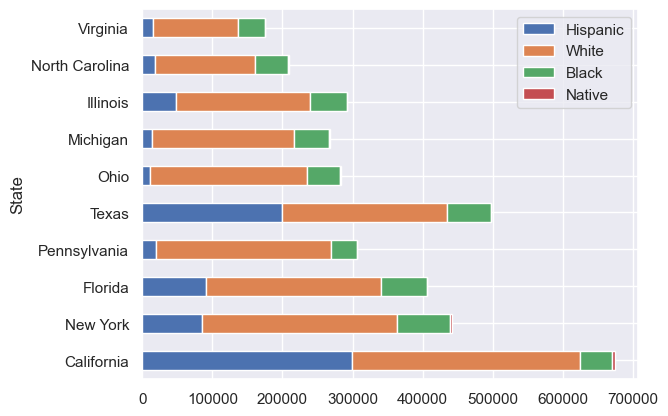

In [9]:
sort_state_papuler.plot.barh(x='State',stacked=True)
plt.show()

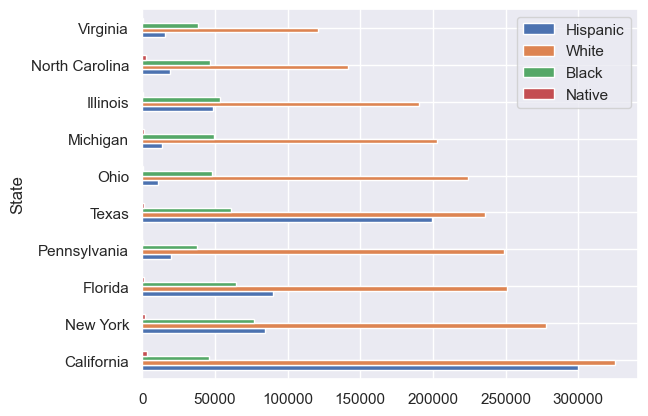

In [10]:
sort_state_papuler.plot.barh(x='State')
plt.show()

In [11]:
df['IncomeQuantile']=pd.qcut(df['Income'],q=5,labels=['Q1','Q2','Q3','Q4','Q5'])


# 1. How many different states are in the data?

In [12]:
df['State'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming', 'Puerto Rico'],
      dtype=object)

In [13]:
df['State'].nunique()

52

# 2. Which county has the largest population?

In [14]:
df.groupby('County')['TotalPop'].sum().sort_values(ascending=False).head(10)

County
Los Angeles    10038388
Cook            5258620
Orange          5025603
Harris          4389138
Maricopa        4018143
Montgomery      3635047
Jefferson       3623682
San Diego       3223096
Clark           2852761
Kings           2746257
Name: TotalPop, dtype: int64

# 3-Which Census Tract has the highest percentage of white residents?

In [15]:
df.groupby(['CensusTract'])['White'].sum().head(10)

CensusTract
1001020100   87.40
1001020200   40.40
1001020300   74.50
1001020400   82.80
1001020500   68.50
1001020600   72.90
1001020700   74.50
1001020801   84.00
1001020802   89.50
1001020900   85.50
Name: White, dtype: float64

# 4-What is the average number of males and females in the census areas?

In [16]:
df.groupby('State')[['Men','Women']].mean()

,Men,Women
State,,
Alabama,1982.30,2107.98
Alaska,2300.36,2091.11
Arizona,2161.92,2190.59
Arkansas,2116.49,2195.77
California,2369.01,2399.69
Colorado,2120.63,2105.88
Connecticut,2102.77,2210.82
Delaware,2056.94,2192.85
District of Columbia,1713.26,1903.97


# 5-Which state has the largest percentage of Hispanic residents?

In [17]:
df.groupby('State')['Hispanic'].sum().sort_values(ascending=False).head(10)

State
California    299541.33
Texas         199511.09
Florida        90255.39
Puerto Rico    88696.64
New York       84770.23
Illinois       48734.30
Arizona        45041.38
New Jersey     37671.40
Colorado       25932.24
New Mexico     22567.76
Name: Hispanic, dtype: float64

# 6-How does the percentage of the Black population vary between states?

In [18]:
state_percentage_of_black=df.groupby('State')['Black'].sum().reset_index(name='count').sort_values(by='count',ascending=False).head(10)
state_percentage_of_black

,State,count
32,New York,76909.33
9,Florida,64240.10
10,Georgia,62956.07
44,Texas,61399.16
13,Illinois,53398.88
22,Michigan,49335.93
35,Ohio,47811.60
33,North Carolina,46767.34
4,California,46084.57
20,Maryland,42837.03


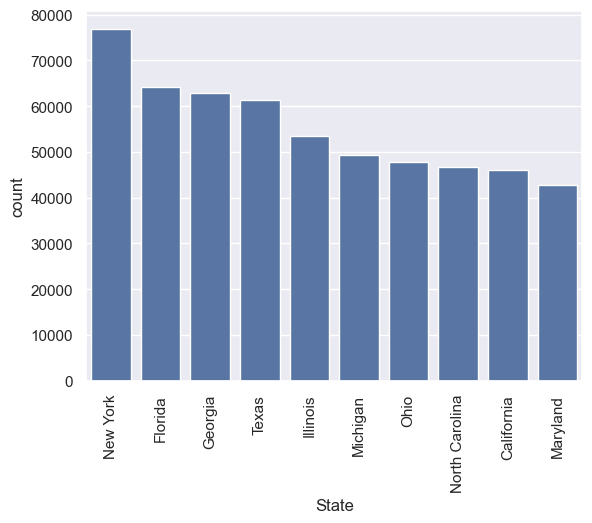

In [19]:
sns.barplot(state_percentage_of_black,x='State',y='count')
# state_percentage_of_black
plt.xticks(rotation=90)
plt.show()

# what is the mean of total sale  for each state 

In [20]:
df['Income']

0       61838.00
1       32303.00
2       44922.00
3       54329.00
4       51965.00
          ...   
73996   21188.00
73997   25781.00
73998   17284.00
73999   22083.00
74000    7953.00
Name: Income, Length: 74001, dtype: float64

In [21]:
df.groupby('State')['Income'].sum()

State
Alabama                 51230503.95
Alaska                  11709854.69
Arizona                 82775454.17
Arkansas                28813714.69
California             540938390.05
Colorado                80623814.17
Connecticut             63127349.04
Delaware                13460089.26
District of Columbia    13453756.69
Florida                215807273.23
Georgia                100168895.73
Hawaii                  25090298.03
Idaho                   14309160.00
Illinois               186059654.34
Indiana                 73545213.65
Iowa                    43752269.69
Kansas                  41528661.21
Kentucky                50625007.21
Louisiana               51930733.69
Maine                   17663451.95
Maryland               110184117.69
Massachusetts          107281227.56
Michigan               144530717.88
Minnesota               84015108.95
Mississippi             25982711.52
Missouri                69380927.52
Montana                 12940719.69
Nebraska              

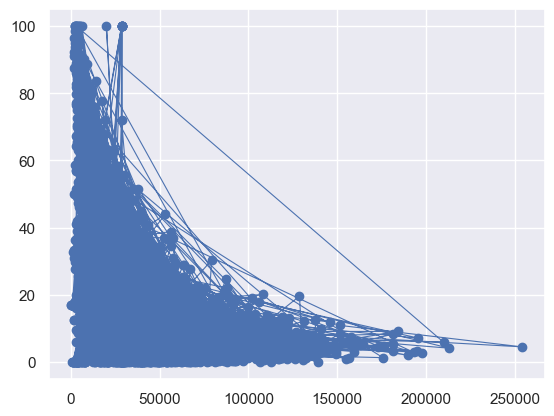

In [22]:
df[['IncomePerCap','Poverty']]
plt.plot(df['IncomePerCap'],df['Poverty'],lw=0.8,marker='o',alpha=1)
plt.show()

In [23]:
corrlation=df.iloc[0:,3:-1]
heatmap_df=corrlation.corr()
# heatmap_df['Income'].
for i ,x in heatmap_df['Income'].items() :
    if x >=0.5 and i!='Income':
        print(i,x)

IncomeErr 0.6141189516733961
IncomePerCap 0.8215056037751802
Professional 0.7260524004253861


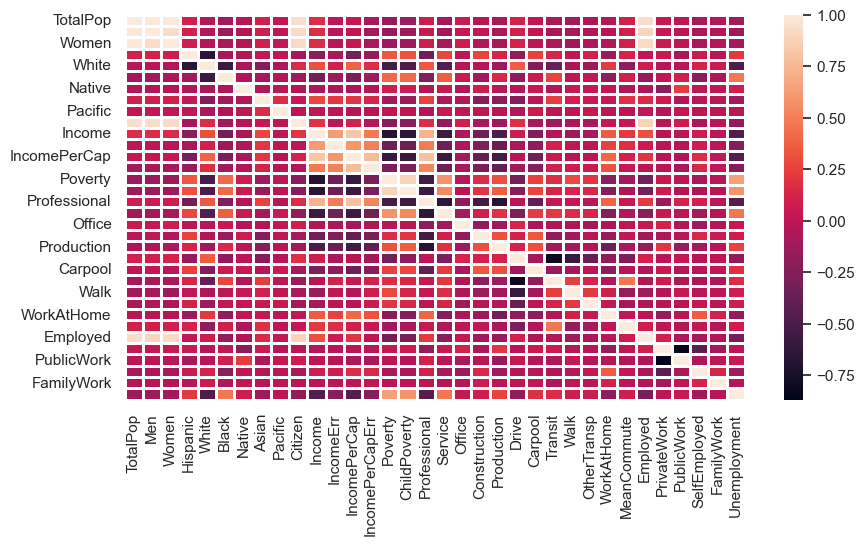

In [24]:
plt.figure(figsize=(10,5))
sns.heatmap(heatmap_df,linewidths=0.8)
plt.show()

In [25]:
ChildPoverty=df.groupby('County')['ChildPoverty'].sum().sort_values(ascending=False).reset_index(name='count').head(10)
ChildPoverty

,County,count
0,Los Angeles,56134.04
1,Cook,32952.53
2,Wayne,27570.46
3,Jefferson,22323.72
4,Kings,21409.80
5,Maricopa,21273.80
6,Harris,21030.96
7,Orange,16648.21
8,Dallas,15686.87
9,Clark,14891.81


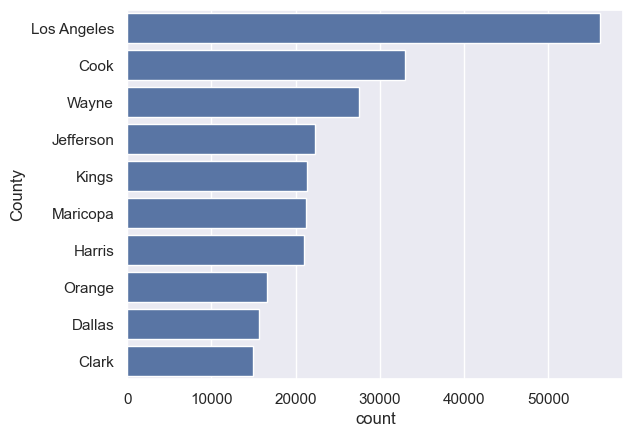

In [26]:
sns.barplot(ChildPoverty,y='County',x='count')
plt.show()

# 11.Is there a relationship between the rate of employment in the public sector (Public Work) and the rate of unemployment (Unemployment) ?

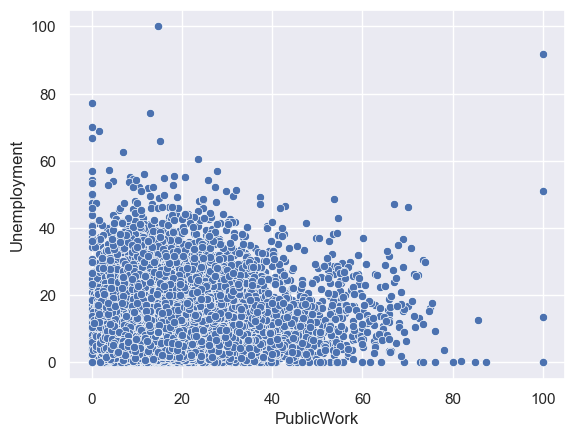

In [27]:

sns.scatterplot(df,x='PublicWork',y='Unemployment')
plt.show()

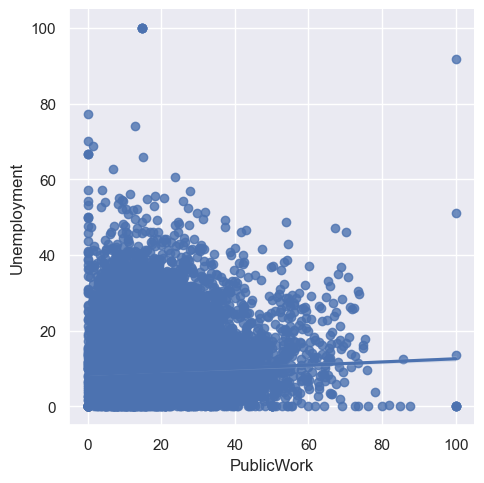

In [28]:
df['PublicWork']
sns.lmplot(df,x='PublicWork',y='Unemployment')
plt.show()

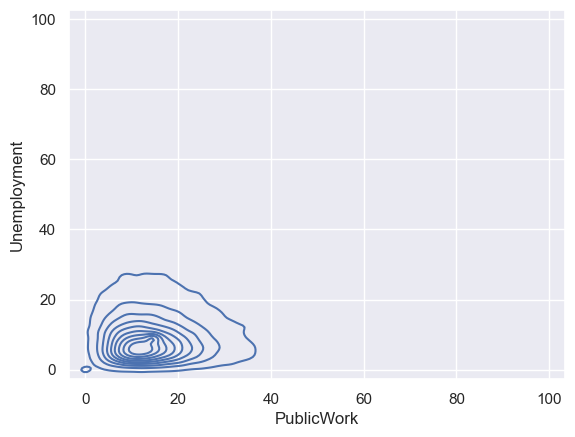

In [29]:
# sns.violinplot(df,x='PublicWork',y='Unemployment')
sns.kdeplot(df,x='PublicWork',y='Unemployment')
plt.show()

In [30]:
df['Unemployment']

0        5.40
1       13.30
2        6.20
3       10.80
4        4.20
         ... 
73996   21.30
73997   22.40
73998   23.30
73999   26.70
74000   20.10
Name: Unemployment, Length: 74001, dtype: float64

In [31]:
group_PublicWork_Unemployment=df.groupby('State')[['Unemployment','PublicWork','PrivateWork','SelfEmployed']].sum().reset_index(names='country')
group_PublicWork_Unemployment

,country,Unemployment,PublicWork,PrivateWork,SelfEmployed
0,Alabama,12611.07,19198.03,92446.35,6218.00
1,Alaska,1547.53,4593.92,10882.38,1188.43
2,Arizona,14446.22,23438.54,119409.53,9499.67
3,Arkansas,5851.73,11714.92,52259.68,4483.13
4,California,82034.49,112671.87,622487.82,69073.10
5,Colorado,9009.27,17998.78,98230.08,8437.54
6,Connecticut,7813.17,10836.33,67087.35,5227.90
7,Delaware,1737.91,3161.49,17676.20,931.74
8,District of Columbia,2080.80,4623.30,12512.40,744.50
9,Florida,42463.44,53558.70,343378.44,26858.47


In [32]:
group_PublicWork_Unemployment.sort_values(by='SelfEmployed',ascending=False)[['country','SelfEmployed']]
# sns.lineplot(group_PublicWork_Unemployment,y='Unemployment',x='SelfEmployed')
# plt.show()

,country,SelfEmployed
4,California,69073.10
44,Texas,36431.72
32,New York,28662.73
9,Florida,26858.47
38,Pennsylvania,16310.64
13,Illinois,14997.90
22,Michigan,14578.33
35,Ohio,14562.94
33,North Carolina,13186.45
10,Georgia,11130.11


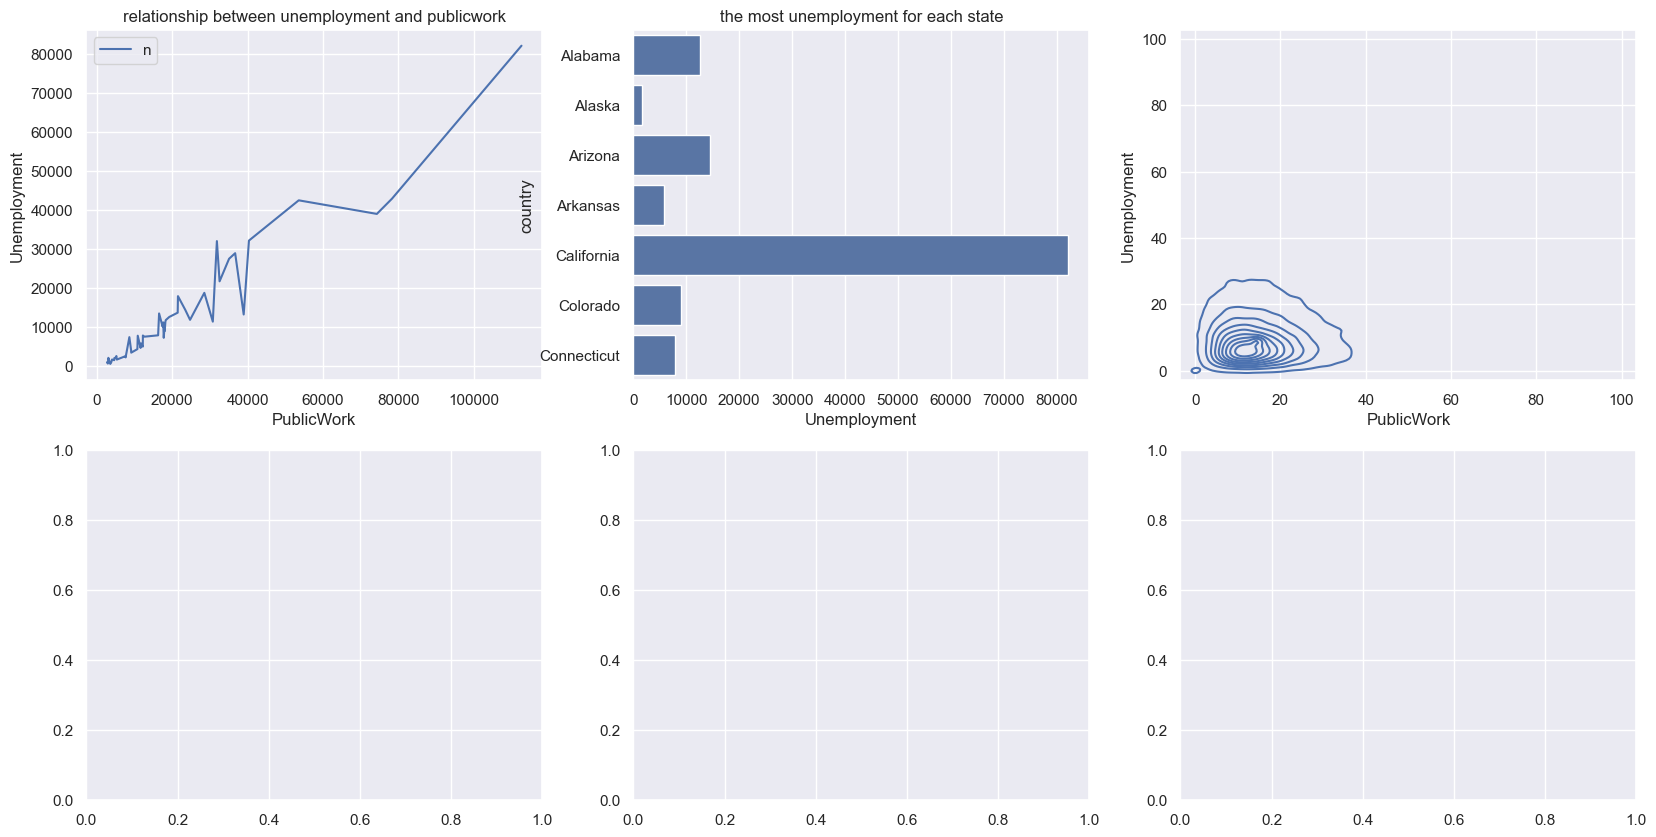

In [38]:
fig,ax=plt.subplots(nrows=2,ncols=3,figsize=(20,10))
sns.lineplot(group_PublicWork_Unemployment,y='Unemployment',x='PublicWork',ax=ax[0,0],label='n')
sns.barplot(group_PublicWork_Unemployment.head(7),y='country',x='Unemployment',ax=ax[0,1])


sns.kdeplot(df,x='PublicWork',y='Unemployment',ax=ax[0,2])
ax[0,0].set_title('relationship between unemployment and publicwork')
ax[0,1].set_title('the most unemployment for each state')

plt.show()

In [34]:

# px.choropleth(df, locations='State',locationmode='USA-states')